# House Price Prediction with Linear Regression

## Objective

Build and evaluate a Linear Regression model to predict house prices based on property features.

The project covers data cleaning, exploratory data analysis, feature selection, categorical encoding, model training, evaluation, visualization, and interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load Dataset

The house prices dataset is loaded using Pandas for further inspection and analysis.

In [4]:
df = pd.read_csv("House_Price_Prediction.csv")

In [5]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [6]:
df.shape

(2000, 10)

In [7]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [9]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [10]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


### Missing Value Analysis

The dataset was checked for missing values using `isnull().sum()`.
There are no missing values in any column, so no missing-value
imputation is required.

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [13]:
df["Price"].describe()

count      2000.000000
mean     537676.855000
std      276428.845719
min       50005.000000
25%      300098.000000
50%      539254.000000
75%      780086.000000
max      999656.000000
Name: Price, dtype: float64

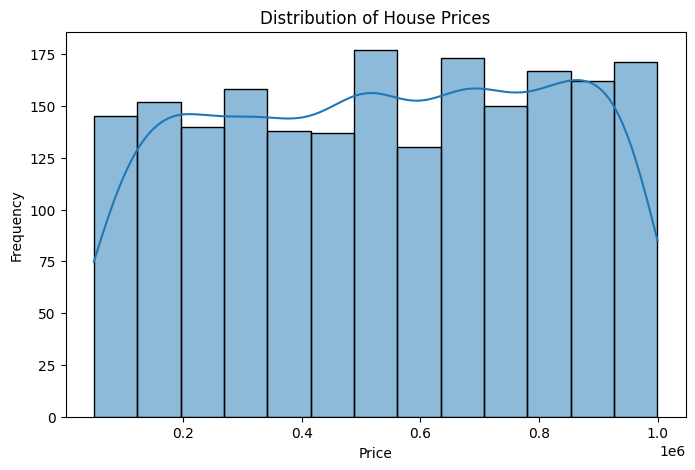

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Price Distribution

The histogram shows the distribution of house prices in the dataset.
The `Price` column is selected as the target variable because the objective
of the project is to predict house prices.

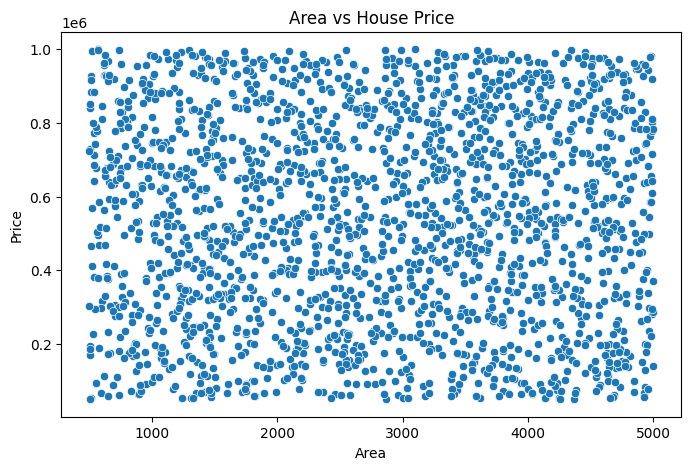

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Area", y="Price")

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

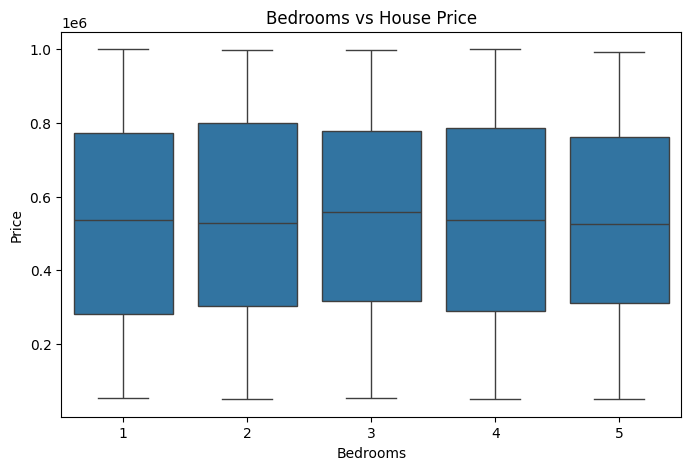

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Bedrooms", y="Price")

plt.title("Bedrooms vs House Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

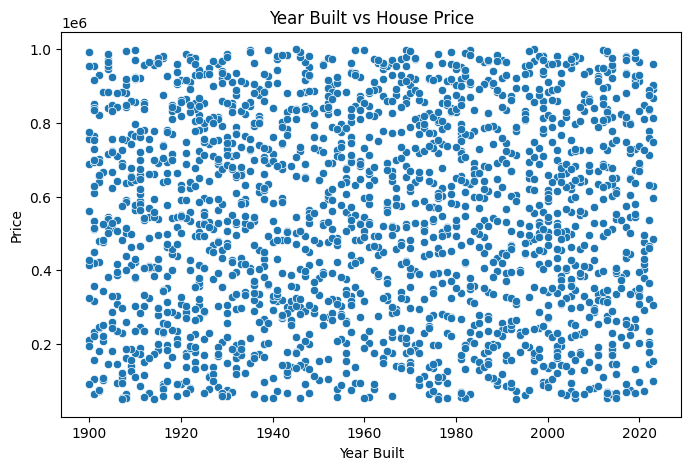

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="YearBuilt", y="Price")

plt.title("Year Built vs House Price")
plt.xlabel("Year Built")
plt.ylabel("Price")

plt.show()

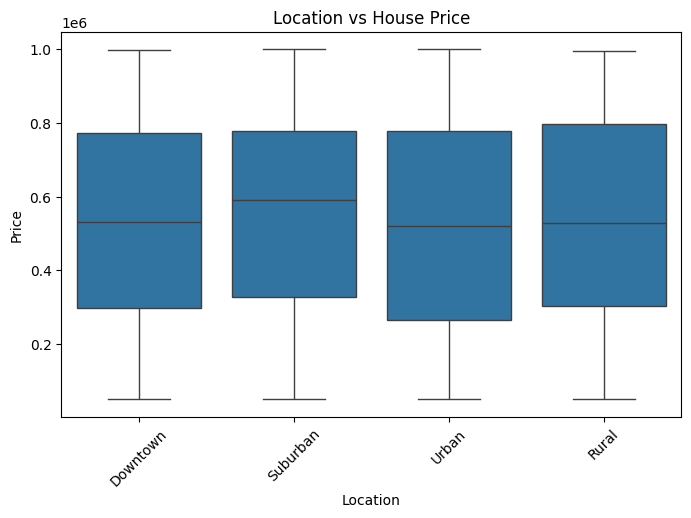

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Location", y="Price")

plt.title("Location vs House Price")
plt.xlabel("Location")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

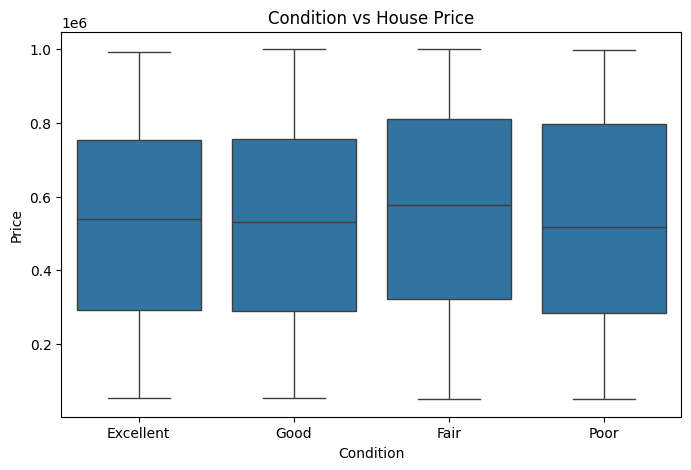

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Condition", y="Price")

plt.title("Condition vs House Price")
plt.xlabel("Condition")
plt.ylabel("Price")

plt.show()

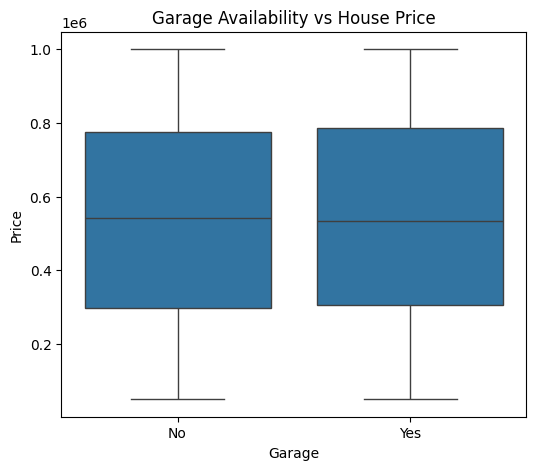

In [20]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="Garage", y="Price")

plt.title("Garage Availability vs House Price")
plt.xlabel("Garage")
plt.ylabel("Price")

plt.show()

In [21]:
features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Location",
    "Condition",
    "Garage"
]

target = "Price"

X = df[features]
y = df[target]

### Feature Selection

The target variable is `Price`.

The selected predictor variables are:

- Area
- Bedrooms
- Bathrooms
- Floors
- YearBuilt
- Location
- Condition
- Garage

The `Id` column was excluded because it is only an identifier and does
not provide meaningful information about house prices.

In [22]:
correlation = df.select_dtypes(include=np.number).corr()

correlation

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


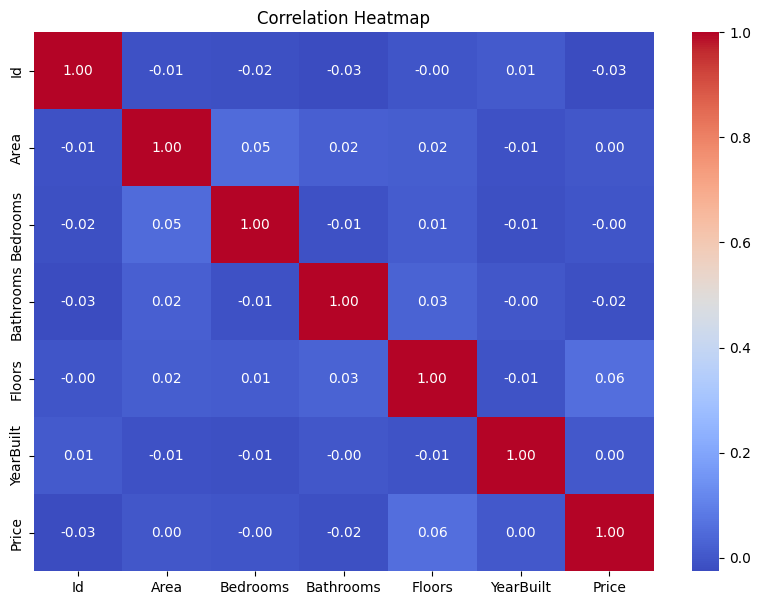

In [23]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [24]:
price_correlation = correlation["Price"].sort_values(ascending=False)

print(price_correlation)

Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Id          -0.025643
Name: Price, dtype: float64


### Correlation Analysis

The correlation matrix was used to understand the relationship between
numerical features and house price. The dataset shows relatively weak
linear correlations between most numerical variables and the target
variable. Therefore, categorical variables such as location, condition,
and garage availability are also included in the model after one-hot
encoding.

In [25]:
numeric_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]

categorical_features = [
    "Location",
    "Condition",
    "Garage"
]

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 8)
Testing data: (400, 8)


In [29]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [30]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('regressor', LinearRegression())])

In [31]:
y_pred = linear_model.predict(X_test)

In [32]:
print(y_pred[:10])

[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512 521375.92025826 523320.18080583 578133.64353335
 545899.64738458 577368.69940644]


In [33]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,514764,521988.221898
1,694256,549119.311967
2,66375,487101.222356
3,650243,539752.743993
4,223285,553242.248725
5,468127,521375.920258
6,513002,523320.180806
7,911525,578133.643533
8,723265,545899.647385
9,339416,577368.699406


In [34]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 78321466146.0328


In [35]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 279859.72583784326


In [36]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.006717808430749761


In [37]:
print("Model Evaluation")
print("----------------------------")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation
----------------------------
Mean Squared Error (MSE): 78321466146.0328
Root Mean Squared Error (RMSE): 279859.72583784326
R² Score: -0.006717808430749761


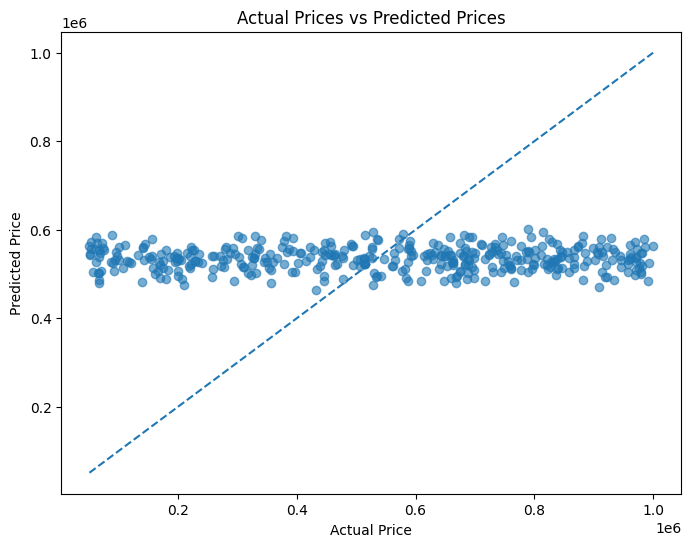

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual Prices vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

### Actual vs Predicted Prices

The scatter plot compares the actual house prices with the prices
predicted by the Linear Regression model. Points closer to the diagonal
line indicate more accurate predictions.

In [39]:
residuals = y_test - y_pred

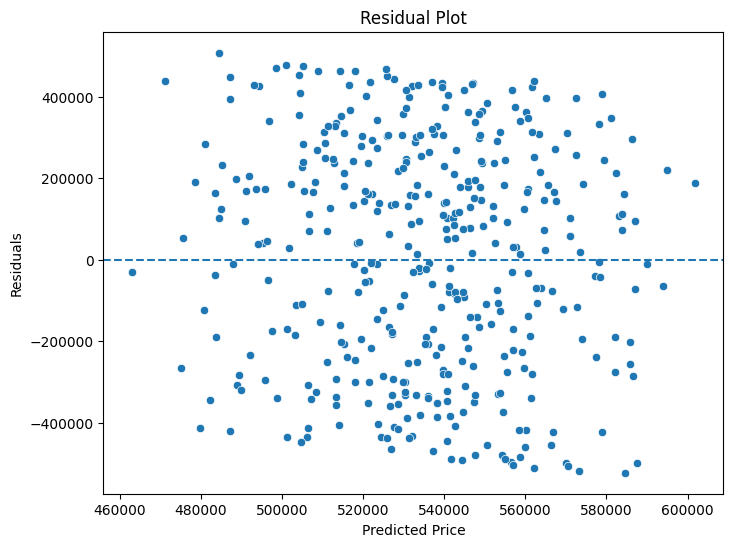

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

### Residual Analysis

Residuals represent the difference between the actual and predicted
house prices.

A good regression model should have residuals distributed randomly
around zero without a clear systematic pattern. The residual plot is
used to identify potential patterns or errors in the predictions.

In [41]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = linear_model.named_steps["regressor"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficient_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
3,num__Floors,23727.983633,23727.983633
10,cat__Condition_Fair,20279.424861,20279.424861
11,cat__Condition_Good,-16744.927821,16744.927821
8,cat__Location_Urban,-12746.572142,12746.572142
7,cat__Location_Suburban,11484.336584,11484.336584
2,num__Bathrooms,-9662.248234,9662.248234
9,cat__Condition_Excellent,-3803.882985,3803.882985
6,cat__Location_Rural,1289.888789,1289.888789
13,cat__Garage_No,-1186.765289,1186.765289
14,cat__Garage_Yes,1186.765289,1186.765289


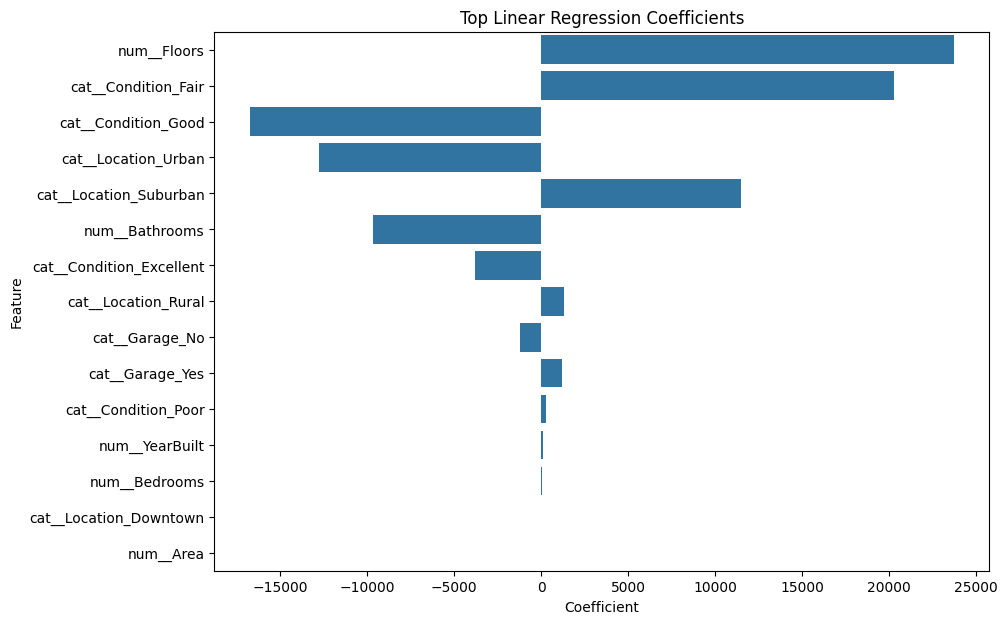

In [42]:
top_coefficients = coefficient_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Linear Regression Coefficients")

plt.show()

### Coefficient Analysis

The coefficients indicate how each feature is associated with the
predicted house price while keeping the other features constant.

A positive coefficient indicates an increase in the predicted price
when that feature increases, while a negative coefficient indicates a
decrease in the predicted price.

For categorical variables, the coefficients represent the effect of
the corresponding one-hot encoded category relative to the omitted
reference category.

In [43]:
from sklearn.linear_model import Ridge

In [44]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("----------------------------")
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression
----------------------------
MSE: 78321066392.83418
RMSE: 279859.0116341337
R² Score: -0.006712670137458687


In [45]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R2 Score": [
        r2,
        ridge_r2
    ]
})

results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,7.832147e+10,279859.725838,-0.006718
1,Ridge Regression,7.832107e+10,279859.011634,-0.006713


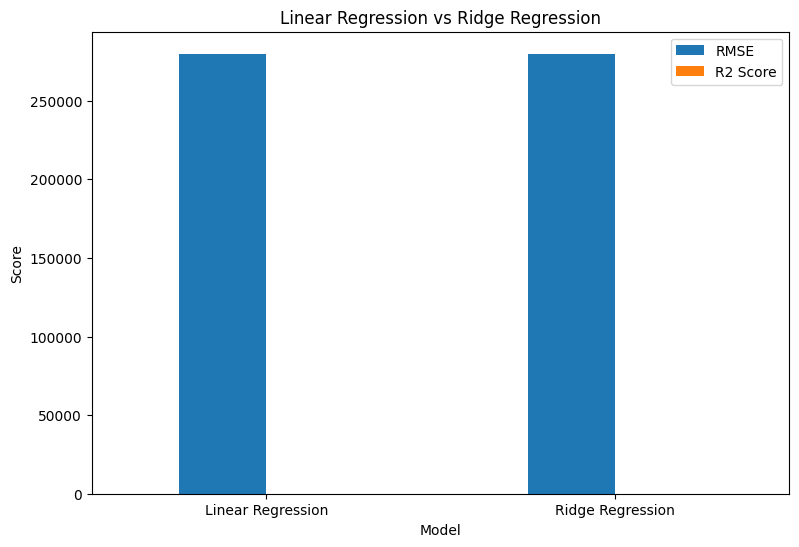

In [46]:
results.set_index("Model")[["RMSE", "R2 Score"]].plot(
    kind="bar",
    figsize=(9,6)
)

plt.title("Linear Regression vs Ridge Regression")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

# Conclusion

In this project, a Linear Regression model was developed to predict house
prices using numerical and categorical property features.

The dataset was explored using descriptive statistics and visualizations.
Missing values and duplicate records were also checked during the data
cleaning process.

The features Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location,
Condition, and Garage were selected for prediction. The Id column was
excluded because it is only an identifier and does not provide meaningful
information for predicting house prices.

Categorical variables were converted into numerical features using
One-Hot Encoding. The dataset was divided into 80% training data and 20%
testing data.

The Linear Regression model was evaluated using Mean Squared Error (MSE),
Root Mean Squared Error (RMSE), and R² Score. Actual versus predicted
price and residual plots were used to visually evaluate model performance.

Ridge Regression was also implemented and compared with Linear Regression.
The model comparison was performed using MSE, RMSE, and R² Score.

Overall, this project demonstrates how regression techniques can be used
to predict house prices and how model evaluation metrics can be used to
compare different regression approaches.